<a href="https://colab.research.google.com/github/nurilhuda05/PCVK_Ganjil_2026/blob/main/P5_17_Muhammad_Nuril_Huda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====

import sys
import platform
import hashlib
import datetime
import zoneinfo

NAMA = 'Muhammad Nuril Huda'
NIM = '244107020004'
N = int(NIM[-3:])
PARAM = {
 'bins' : 2 ** ((N % 4) + 3),
 'clip' : round(1.0 + (N % 5) * 0.5, 1),
 'tile' : (N % 4) + 2,
 'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)

for k, v in PARAM.items():
 print('%-6s :' % k, v)

print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())

kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Muhammad Nuril Huda
NIM : 244107020004 | N = 4
bins   : 8
clip   : 3.0
tile   : 2
L      : 4
WAKTU : 2026-09-22 15:08:33 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : a23e5d7f991d89e0


# **E-1 PERCOBAAN HISTOGRAM**

**Menghubungkan Ke Drive**

In [39]:
from google.colab import drive

drive.mount('/content/drive')

CONTOH = '/content/drive/MyDrive/Semester 5/PCVK/images'
BASE = '/content/drive/MyDrive/Semester 5/PCVK/images/' + NIM

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Import Library**

In [40]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

**Membuat Histogram Dari Gambar Contoh**

<BarContainer object of 256 artists>

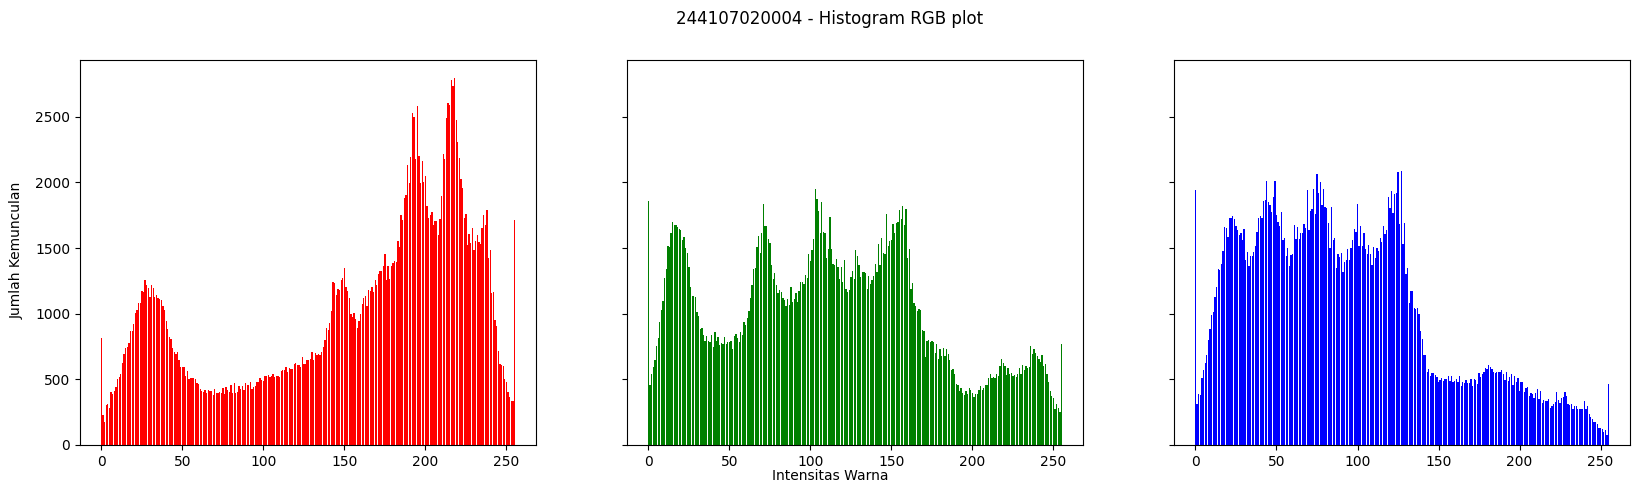

In [46]:
#membuat histogram image (manual)
img = cv.imread(CONTOH + '/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20,5), sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

**Membuat Histogram Dari KTM1b**

<BarContainer object of 256 artists>

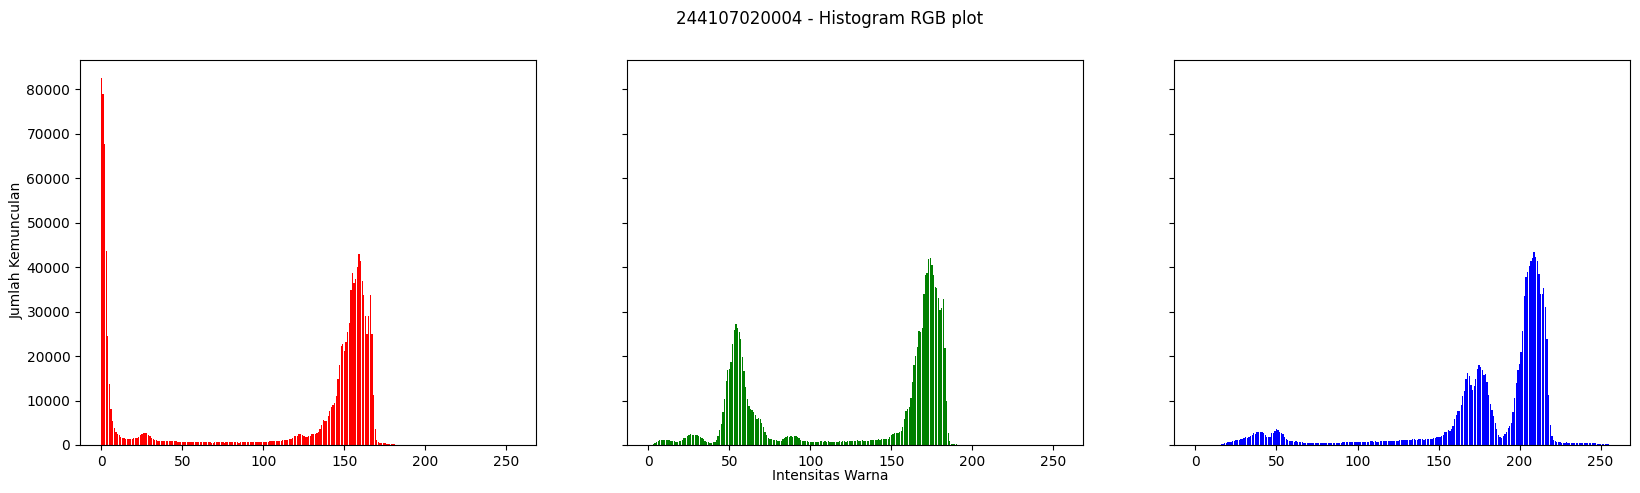

In [47]:
#membuat histogram image (manual)
ktm1b = cv.imread(BASE + '/KTM1b.jpg')
ktm1b = cv.cvtColor(ktm1b, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(ktm1b)
names = np.arange(256)

red_ktm1b = [0]*256
green_ktm1b = [0]*256
blue_ktm1b = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red_ktm1b[ktm1b[y][x][0]] += 1
        green_ktm1b[ktm1b[y][x][1]] += 1
        blue_ktm1b[ktm1b[y][x][2]] += 1

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(20,5), sharex=True, sharey=True)

fig.suptitle(NIM + ' - Histogram RGB plot')

fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')

fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red_ktm1b, color='red')
axs[1].bar(names, green_ktm1b, color='green')
axs[2].bar(names, blue_ktm1b, color='blue')

**Pertanyaan Praktikum E1**

**Pertanyaan 1**

Lena

<BarContainer object of 256 artists>

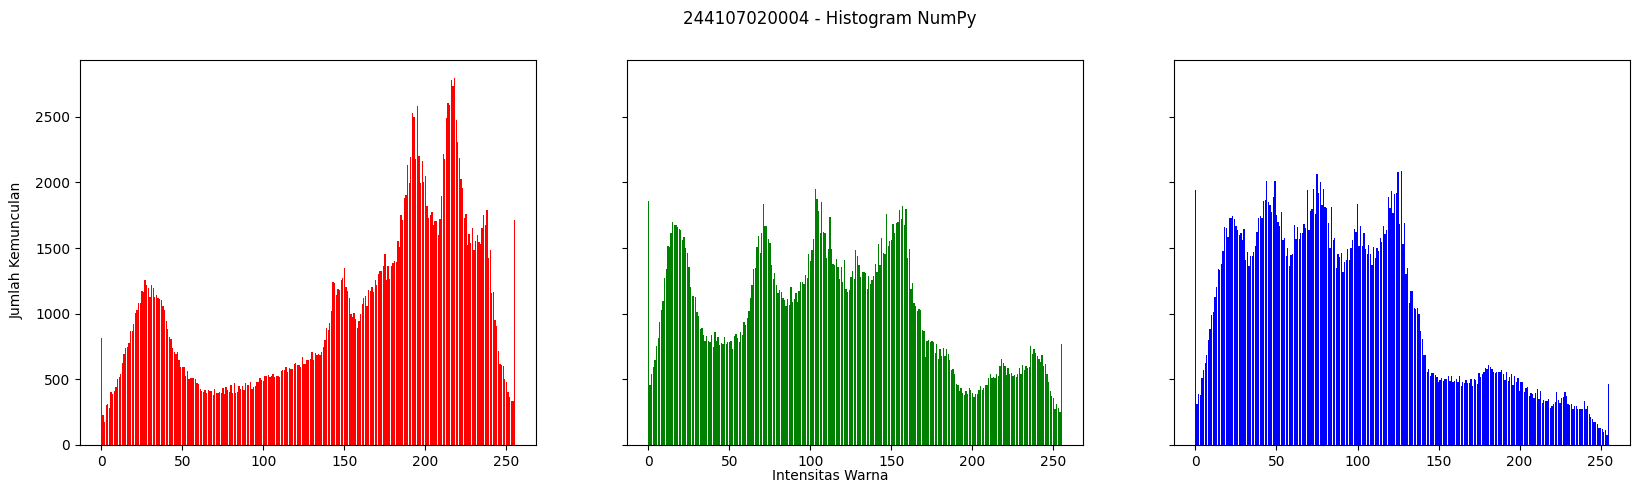

In [48]:
# Histogram Menggunakan Numpy
hist_numpy_red, _ = np.histogram(
    img[:,:,0],
    bins=256,
    range=(0,256)
)

hist_numpy_green, _ = np.histogram(
    img[:,:,1],
    bins=256,
    range=(0,256)
)

hist_numpy_blue, _ = np.histogram(
    img[:,:,2],
    bins=256,
    range=(0,256)
)

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

fig.suptitle(NIM + ' - Histogram NumPy')

fig.text(0.09, 0.5,'Jumlah Kemunculan',va='center',rotation='vertical')

fig.text(0.5, 0.04,'Intensitas Warna',ha='center')

axs[0].bar(names, hist_numpy_red, color='red')
axs[1].bar(names, hist_numpy_green, color='green')
axs[2].bar(names, hist_numpy_blue, color='blue')


<BarContainer object of 256 artists>

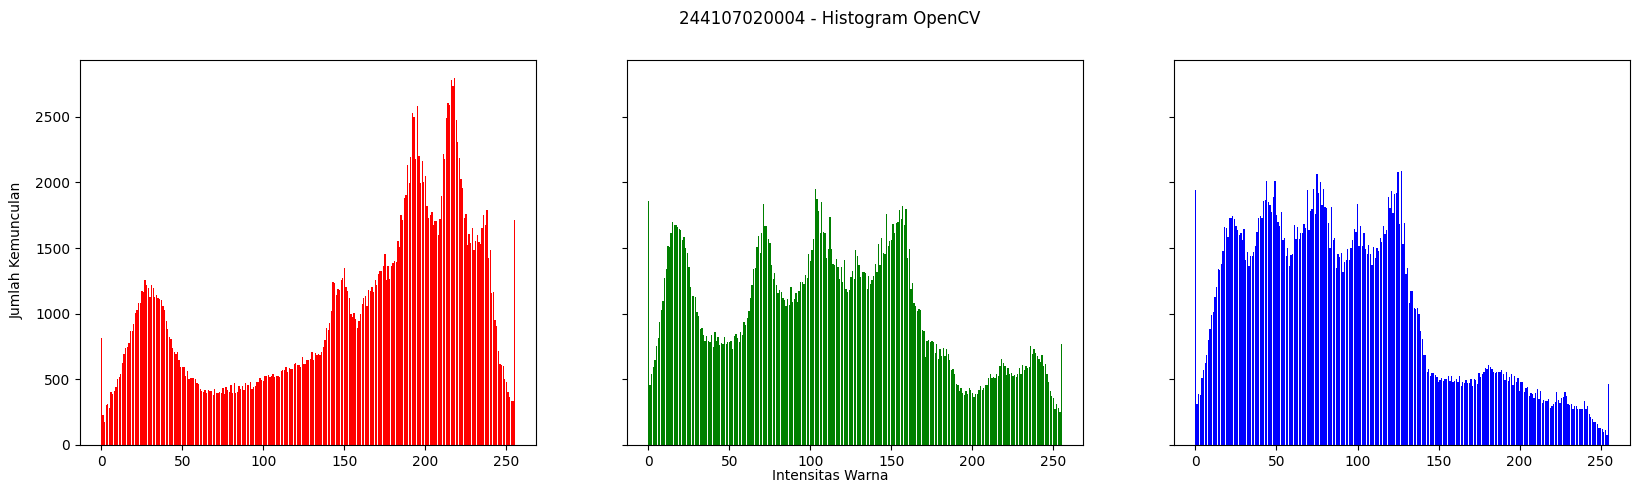

In [49]:
# Histogram Menggunakan OpenCV
hist_cv_red = cv.calcHist(
    [img], [0], None, [256], [0,256]
).flatten()

hist_cv_green = cv.calcHist(
    [img], [1], None, [256], [0,256]
).flatten()

hist_cv_blue = cv.calcHist(
    [img], [2], None, [256], [0,256]
).flatten()

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

fig.suptitle(NIM + ' - Histogram OpenCV')

fig.text(0.09, 0.5,'Jumlah Kemunculan',va='center',rotation='vertical')

fig.text(0.5, 0.04,'Intensitas Warna',ha='center')

axs[0].bar(names, hist_cv_red, color='red')
axs[1].bar(names, hist_cv_green, color='green')
axs[2].bar(names, hist_cv_blue, color='blue')

In [51]:
# Membandingkan hasil NumPy dan OpenCV

selisih_red = np.max(np.abs(hist_numpy_red - hist_cv_red))

selisih_green = np.max(np.abs(hist_numpy_green - hist_cv_green))

selisih_blue = np.max(np.abs(hist_numpy_blue - hist_cv_blue))

# Membandingkan hasil NumPy dan Manual
diff_red = np.max(np.abs(np.array(red) - hist_numpy_red))
diff_green = np.max(np.abs(np.array(green) - hist_numpy_green))
diff_blue = np.max(np.abs(np.array(blue) - hist_numpy_blue))


print('Selisih maksimum NumPy vs OpenCV')
print('Red   :', selisih_red)
print('Green :', selisih_green)
print('Blue  :', selisih_blue)
print('')
print('Selisih maksimum Manual vs NumPy')
print('Red   :', diff_red)
print('Green :', diff_green)
print('Blue  :', diff_blue)

Selisih maksimum NumPy vs OpenCV
Red   : 0.0
Green : 0.0
Blue  : 0.0

Selisih maksimum Manual vs NumPy
Red   : 0
Green : 0
Blue  : 0


KTM_1b

<BarContainer object of 256 artists>

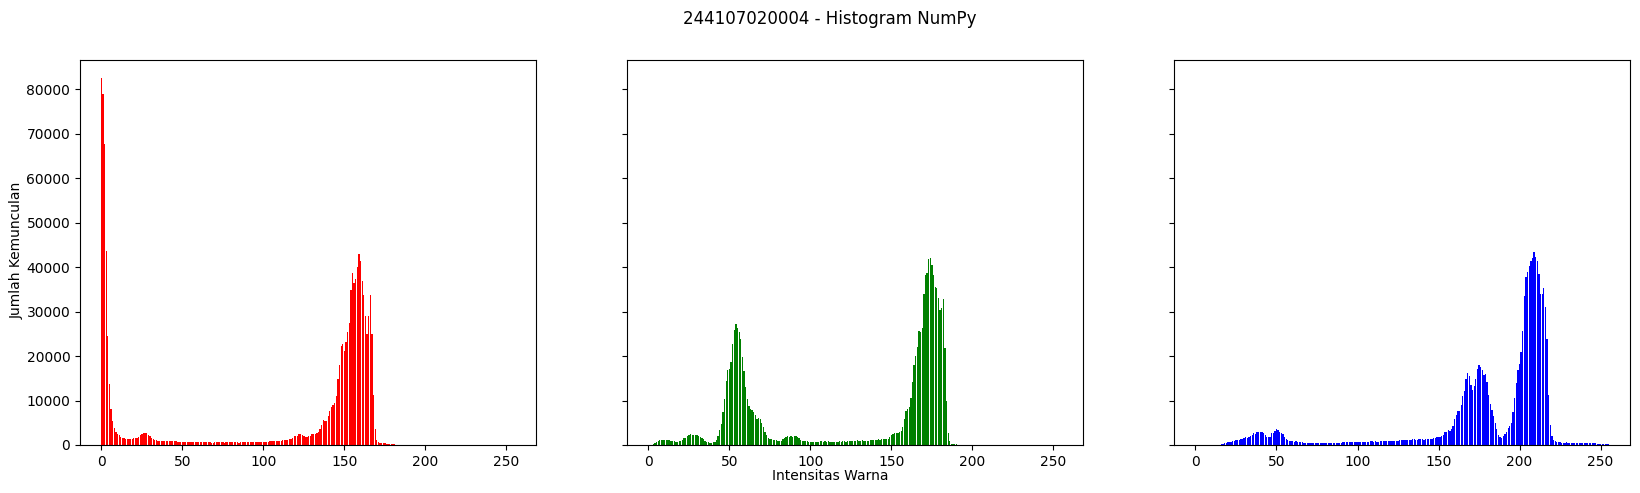

In [53]:
# Histogram Menggunakan Numpy
hist_numpy_red_ktm1b, _ = np.histogram(
    ktm1b[:,:,0],
    bins=256,
    range=(0,256)
)

hist_numpy_green_ktm1b, _ = np.histogram(
    ktm1b[:,:,1],
    bins=256,
    range=(0,256)
)

hist_numpy_blue_ktm1b, _ = np.histogram(
    ktm1b[:,:,2],
    bins=256,
    range=(0,256)
)

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

fig.suptitle(NIM + ' - Histogram NumPy')

fig.text(0.09, 0.5,'Jumlah Kemunculan',va='center',rotation='vertical')

fig.text(0.5, 0.04,'Intensitas Warna',ha='center')

axs[0].bar(names, hist_numpy_red_ktm1b, color='red')
axs[1].bar(names, hist_numpy_green_ktm1b, color='green')
axs[2].bar(names, hist_numpy_blue_ktm1b, color='blue')

<BarContainer object of 256 artists>

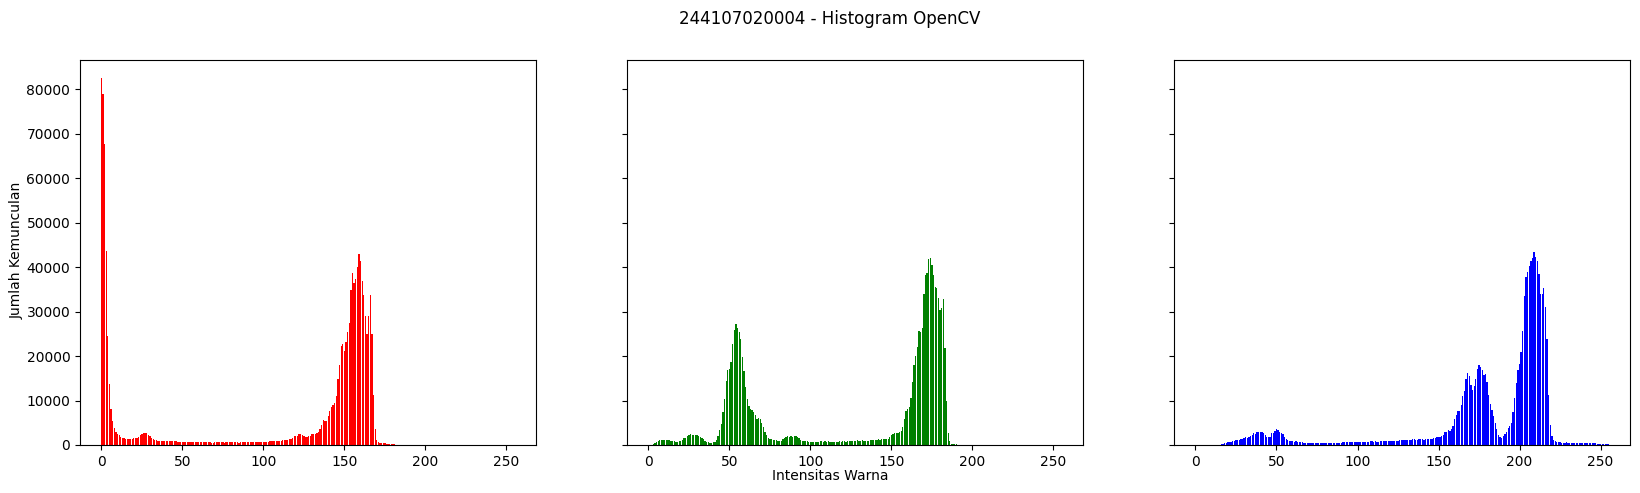

In [54]:
# Histogram Menggunakan OpenCV
hist_cv_red_ktm1b = cv.calcHist(
    [ktm1b], [0], None, [256], [0,256]
).flatten()

hist_cv_green_ktm1b = cv.calcHist(
    [ktm1b], [1], None, [256], [0,256]
).flatten()

hist_cv_blue_ktm1b = cv.calcHist(
    [ktm1b], [2], None, [256], [0,256]
).flatten()

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

fig.suptitle(NIM + ' - Histogram OpenCV')

fig.text(0.09, 0.5,'Jumlah Kemunculan',va='center',rotation='vertical')

fig.text(0.5, 0.04,'Intensitas Warna',ha='center')

axs[0].bar(names, hist_cv_red_ktm1b, color='red')
axs[1].bar(names, hist_cv_green_ktm1b, color='green')
axs[2].bar(names, hist_cv_blue_ktm1b, color='blue')

In [55]:
# Membandingkan hasil NumPy dan OpenCV

selisih_red_ktm1b = np.max(np.abs(hist_numpy_red_ktm1b - hist_cv_red_ktm1b))

selisih_green_ktm1b = np.max(np.abs(hist_numpy_green_ktm1b - hist_cv_green_ktm1b))

selisih_blue_ktm1b = np.max(np.abs(hist_numpy_blue_ktm1b - hist_cv_blue_ktm1b))

# Membandingkan hasil NumPy dan Manual
diff_red_ktm1b = np.max(np.abs(np.array(red_ktm1b) - hist_numpy_red_ktm1b))
diff_green_ktm1b = np.max(np.abs(np.array(green_ktm1b) - hist_numpy_green_ktm1b))
diff_blue_ktm1b = np.max(np.abs(np.array(blue_ktm1b) - hist_numpy_blue_ktm1b))


print('Selisih maksimum NumPy vs OpenCV')
print('Red   :', selisih_red_ktm1b)
print('Green :', selisih_green_ktm1b)
print('Blue  :', selisih_blue_ktm1b)
print('')
print('Selisih maksimum Manual vs NumPy')
print('Red   :', diff_red_ktm1b)
print('Green :', diff_green_ktm1b)
print('Blue  :', diff_blue_ktm1b)

Selisih maksimum NumPy vs OpenCV
Red   : 0.0
Green : 0.0
Blue  : 0.0

Selisih maksimum Manual vs NumPy
Red   : 0
Green : 0
Blue  : 0


**Pertanyaan 2**

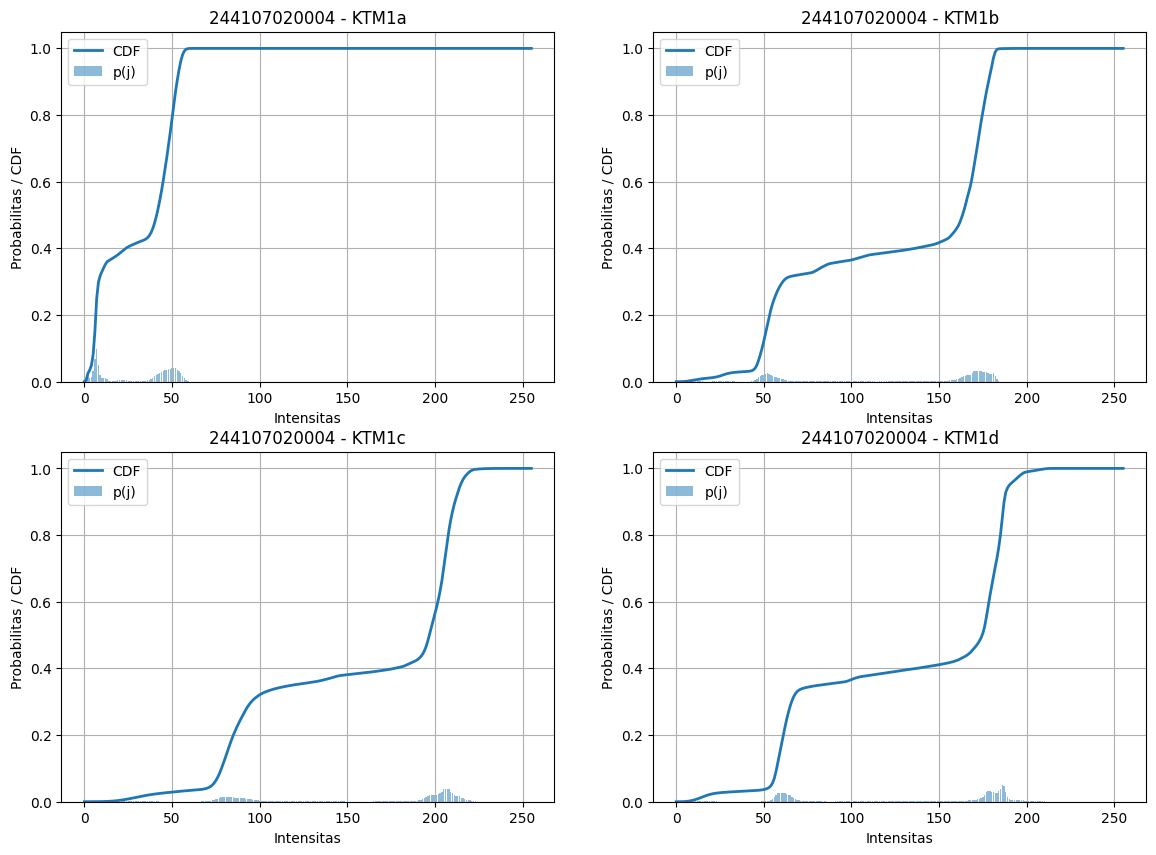

In [57]:
# Membaca 4 citra KTM
ktm1a = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
ktm1b = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)
ktm1c = cv.imread(BASE + '/KTM1c.jpg', cv.IMREAD_GRAYSCALE)
ktm1d = cv.imread(BASE + '/KTM1d.jpg', cv.IMREAD_GRAYSCALE)

# Menyimpan citra dalam list
ktm = [ktm1a, ktm1b, ktm1c, ktm1d]
nama = ['KTM1a', 'KTM1b', 'KTM1c', 'KTM1d']

# Membuat figure 2 x 2
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

for ax, img, nama_img in zip(axs.ravel(), ktm, nama):

    # Histogram
    h, _ = np.histogram(img, bins=256, range=(0, 256))

    # Histogram ternormalisasi p(j)
    p = h / img.size

    # CDF
    cdf = np.cumsum(p)

    # Plot histogram ternormalisasi
    ax.bar(np.arange(256), p, alpha=0.5, label='p(j)')

    # Plot CDF
    ax.plot(np.arange(256), cdf, linewidth=2, label='CDF')

    ax.set_title(NIM + ' - ' + nama_img)
    ax.set_xlabel('Intensitas')
    ax.set_ylabel('Probabilitas / CDF')
    ax.legend()
    ax.grid()



Berdasarkan histogram ternormalisasi dan kurva CDF pada KTM1a sampai KTM1d, terlihat adanya perbedaan distribusi intensitas pada setiap citra. Pada KTM1a, kurva CDF mengalami kenaikan yang cukup besar pada intensitas rendah, terutama sekitar 0–60, yang menunjukkan bahwa banyak piksel memiliki nilai intensitas rendah sehingga citra terlihat lebih gelap. Sementara itu, pada KTM1c dan KTM1d, kenaikan CDF utama berada pada intensitas yang lebih tinggi, sehingga menunjukkan bahwa citra memiliki lebih banyak piksel dengan intensitas yang lebih terang.

Perbedaan tersebut berkaitan dengan kondisi pencahayaan saat proses akuisisi citra pada Pertemuan 2. KTM1a diambil dalam kondisi ruangan yang lebih gelap sehingga cahaya yang diterima kamera lebih sedikit dan distribusi piksel cenderung berada pada intensitas rendah. Pada kondisi pencahayaan yang lebih kuat, seperti penggunaan flash atau pengambilan gambar di luar ruangan, distribusi intensitas bergeser ke nilai yang lebih tinggi. Hal ini menyebabkan bentuk histogram dan kurva CDF setiap citra berbeda.

**Pertanyaan 3**

<BarContainer object of 256 artists>

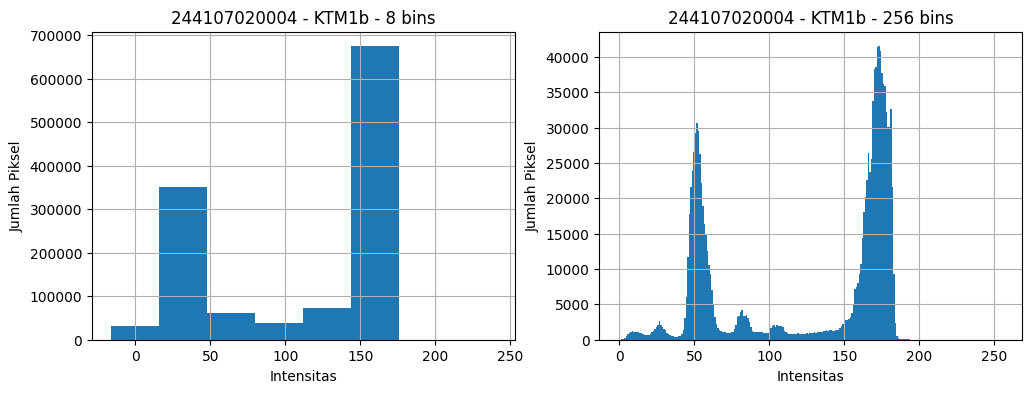

In [62]:
ktm1b = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)

# Histogram dengan jumlah bin sesuai PARAM
hist_param, batas_param = np.histogram(
    ktm1b,
    bins=PARAM['bins'],
    range=(0, 256)
)

# Histogram dengan 256 bin
hist_256, batas_256 = np.histogram(
    ktm1b,
    bins=256,
    range=(0, 256)
)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Histogram PARAM['bins']
axs[0].set_title(NIM + ' - KTM1b - ' + str(PARAM['bins']) + ' bins')
axs[0].set_xlabel('Intensitas')
axs[0].set_ylabel('Jumlah Piksel')
axs[0].grid()
axs[0].bar(batas_param[:-1],hist_param,width=256 / PARAM['bins'])

# Histogram 256 bins
axs[1].set_title(NIM + ' - KTM1b - 256 bins')
axs[1].set_xlabel('Intensitas')
axs[1].set_ylabel('Jumlah Piksel')
axs[1].grid()
axs[1].bar(batas_256[:-1],hist_256,width=1)



Berdasarkan hasil perbandingan histogram KTM1b, penggunaan 256 bin memberikan informasi distribusi intensitas yang lebih detail. Setiap tingkat intensitas dari 0 sampai 255 dapat diamati dengan lebih jelas, sehingga puncak dan perubahan kecil pada distribusi piksel masih terlihat. Pada histogram dengan 8 bin, rentang intensitas yang berdekatan digabungkan menjadi satu kelompok sehingga bentuk histogram menjadi lebih sederhana.

Informasi yang hilang ketika jumlah bin dikurangi adalah detail persebaran piksel pada setiap tingkat intensitas. Sebagai contoh, pada histogram 256 bin terlihat adanya beberapa puncak dan perubahan distribusi di sekitar intensitas 50 serta 170–180. Pada histogram 8 bin, detail tersebut digabungkan ke dalam rentang yang lebih besar sehingga perubahan kecil tersebut tidak dapat diamati secara jelas.